## Test notebook

For testing the Perceptron class and its methods

----------------------------------------
Epoch 1/1000
Input: [1. 2. 1.], Output: 1
Weighted Sum: 2.0
Predicted Output: 1
Error: 0
No weight update needed
Input: [ 1. -1.  1.], Output: 0
Weighted Sum: 0.5
Predicted Output: 1
Error: -1
Updated Weights: [0.4 0.6 0.4]
Input: [ 1. -1. -1.], Output: 0
Weighted Sum: -0.6
Predicted Output: 0
Error: 0
No weight update needed
Input: [1. 1. 1.], Output: 1
Weighted Sum: 1.4
Predicted Output: 1
Error: 0
No weight update needed
Input: [1. 2. 2.], Output: 1
Weighted Sum: 2.4000000000000004
Predicted Output: 1
Error: 0
No weight update needed
Input: [ 1. -2. -1.], Output: 0
Weighted Sum: -1.2
Predicted Output: 0
Error: 0
No weight update needed
Number of Weight Updates: 1
----------------------------------------
Epoch 2/1000
Input: [1. 2. 1.], Output: 1
Weighted Sum: 2.0
Predicted Output: 1
Error: 0
No weight update needed
Input: [ 1. -1.  1.], Output: 0
Weighted Sum: 0.20000000000000007
Predicted Output: 1
Error: -1
Updated Weights: [0.3 0.7 0.3]
Inp

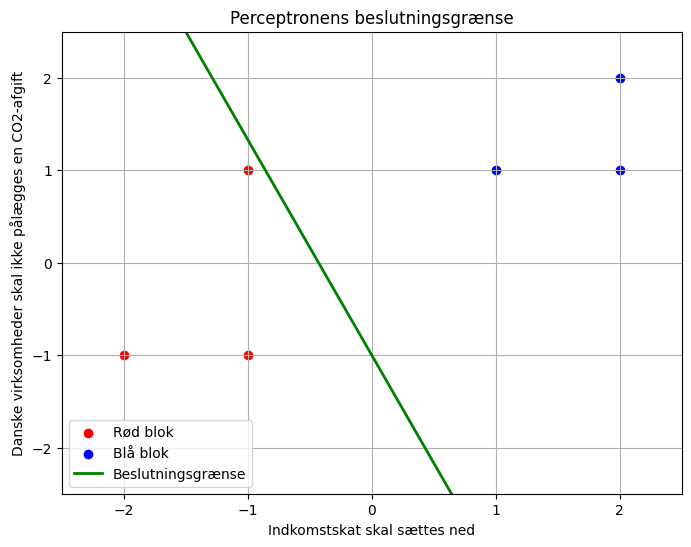

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from py_perceptron import PyPerceptron

def heaviside_step(x):
    # Heaviside step function
    return 1 if x >= 0 else 0


def plot_decision_boundary(weights, X, y):
    w0, w1, w2 = weights

    # Formula (with only 2D data): w0 + w1*x1 + w2*x2 = 0
    # Rearranging gives: x2 = -(w0/w2) - (w1/w2)*x1
    x1_values = np.linspace(-2.5, 2.5, 100) # Create a list of x1 values
    x2_values = -(w0 / w2) - (w1 / w2) * x1_values

    # Formula:
    # print(f"Decision Boundary: x2 = {-(w0 / w2)} - ({w1 / w2}) * x1")
    # print(f"Decision Boundary: 0 = {w0} + {w1} * x1 + {w2} * x2")

    # Plot data points
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Rød blok')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Blå blok')

    # Plot decision boundary
    plt.plot(x1_values, x2_values, color='green', label='Beslutningsgrænse', linewidth=2)

    # Axis labels and legend
    plt.xlabel('Indkomstskat skal sættes ned')
    plt.ylabel('Danske virksomheder skal ikke pålægges en CO2-afgift')
    plt.title('Perceptronens beslutningsgrænse')
    plt.xlim(-2.5, 2.5)
    plt.ylim(-2.5, 2.5)
    plt.legend()
    plt.grid(True)
    plt.show()


def main():
    learning_rate = 0.1
    n_epochs = 1000
    activation_function = heaviside_step
    # init_weight_value = np.random.uniform(-1, 1, 3)  # Random initialization of weights
    init_weight_value = 0.5  # Initialize weights to a constant value



    # Initialize the perceptron with 2 input features
    p = PyPerceptron(learning_rate, n_epochs, activation_function, init_weight_value, verbose=True)

    # Train the perceptron with some sample data 'kandidattest' from aimat.dk
    # "From a scale of -2 to 2, how much do you agree with this political statement?"
    training_data = np.array([
        [2, 1],
        [-1, 1],
        [-1, -1],
        [1, 1],
        [2, 2],
        [-2, -1]
    ])
    target_labels = np.array([1, 0, 0, 1, 1, 0])  # Example labels for the test data

    X_data = p.fit(training_data)
    p.train(X_data, target_labels)

    # for inputs in test_data:
    #     print(f"Input: {inputs}, Prediction: {p.predict(inputs)}")
    # Print the perceptron structure
    p.print_structure()

    plot_decision_boundary(p.weights, training_data, target_labels)

    # Calculate confusion matrix
    # y_true = target_labels
    # y_pred = p.predict(training_data)
    # p.score(y_pred, y_true)

    # p.confusion_matrix(y_true, y_pred)
    


if __name__ == "__main__":
    main()

#### 3D data

----------------------------------------
Epoch 1/1000
Input: [1. 2. 1. 1.], Output: 1
Weighted Sum: 2.5
Predicted Output: 1
Error: 0
No weight update needed
Input: [ 1. -1.  1.  0.], Output: 0
Weighted Sum: 0.5
Predicted Output: 1
Error: -1
Updated Weights: [0.4 0.6 0.4 0.5]
Input: [ 1. -1. -1.  0.], Output: 0
Weighted Sum: -0.6
Predicted Output: 0
Error: 0
No weight update needed
Input: [1. 1. 1. 1.], Output: 1
Weighted Sum: 1.9000000000000001
Predicted Output: 1
Error: 0
No weight update needed
Input: [1. 2. 2. 1.], Output: 1
Weighted Sum: 2.9000000000000004
Predicted Output: 1
Error: 0
No weight update needed
Input: [ 1. -2. -1.  0.], Output: 0
Weighted Sum: -1.2
Predicted Output: 0
Error: 0
No weight update needed
Number of Weight Updates: 1
----------------------------------------
Epoch 2/1000
Input: [1. 2. 1. 1.], Output: 1
Weighted Sum: 2.5
Predicted Output: 1
Error: 0
No weight update needed
Input: [ 1. -1.  1.  0.], Output: 0
Weighted Sum: 0.20000000000000007
Predicted Output:

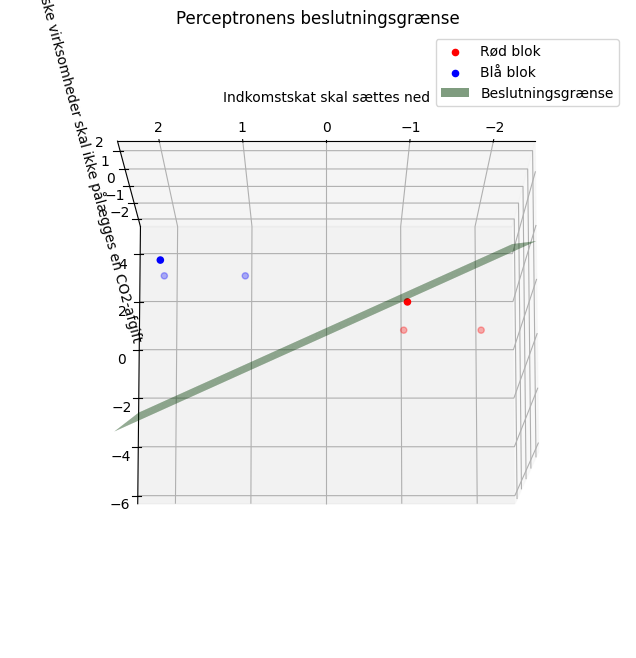

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

perceptron = PyPerceptron(learning_rate=0.1, n_epochs=1000, activation_function=heaviside_step, init_weight_value=0.5)


def plot_decision_boundary_3d(weights, X, y):
    # Extract weights
    w0, w1, w2, w3 = weights

    # Create a meshgrid for 3D plotting
    x1_range = np.linspace(-2.5, 2.5, 100)
    x2_range = np.linspace(-2.5, 2.5, 100)
    X1, X2 = np.meshgrid(x1_range, x2_range)

    # Calculate the decision boundary
    Z = -(w0 + w1 * X1 + w2 * X2) / w3

    # Formula:
    print(f"Decision Boundary: x3 = {-(w0 + w1 * X1 + w2 * X2) / w3}")
    print(f"Decision Boundary: 0 = {w0} + {w1} * x1 + {w2} * x2 + {w3} * x3")

    # Plot data points
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], X[y == 0][:, 2], color='red', label='Rød blok')
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], X[y == 1][:, 2], color='blue', label='Blå blok')
    ax.plot_surface(X1, X2, Z, alpha=0.5, color='green', label='Beslutningsgrænse')
    ax.set_xlabel('Indkomstskat skal sættes ned')
    ax.set_ylabel('Danske virksomheder skal ikke pålægges en CO2-afgift')
    ax.set_title('Perceptronens beslutningsgrænse')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_axis_on()
    ax.legend()
    ax.view_init(elev=-10, azim=90)  # Set the viewing angle 
    ax.grid(True)
    plt.show()


training_data = np.array([
    [2, 1, 1],
    [-1, 1, 0],
    [-1, -1, 0],
    [1, 1, 1],
    [2, 2, 1],
    [-2, -1, 0]
])
target_labels = np.array([1, 0, 0, 1, 1, 0])  # Example labels for the test data

X_data = perceptron.fit(training_data)
perceptron.train(X_data, target_labels)

plot_decision_boundary_3d(perceptron.weights, training_data, target_labels)




### Claims example - 2D simplified data
In our example, we have a target `Handling`, being either `Accepted` or `Rejected`, (1 or 0, respectively).

The simplified data has 2 features:
- `within_30_days`: Whether or not (1 or 0) the claim was made within 30 days of the purchase date.
- `defect_visible_in_attachment`: Whether or not (1 or 0) the defect was visible in the attached image of the piece of clothing.

Additionally, it has a `claim_number` column, which is not relevant for the model, but simply to identify it in the cloud storage.

To load this data, we will use the `pandas` library. The data is stored in a CSV file, which we will read into a DataFrame. We will then convert the DataFrame to a NumPy array for processing.

In [ ]:
import pandas as pd

claims_data = pd.read_csv("data/claims_example_2d.csv", sep=";")
print(claims_data)

  claim_number  within_30_days  defect_visible_in_attachment  handling
0  PCLM0070028               1                             1         1
1  PCLM0070027               1                             1         1
2  PCLM0070026               1                             1         1
3  PCLM0070025               0                             1         1
4  PCLM0076843               0                             0         0
5  PCLM0075964               1                             0         0
6  PCLM0075598               1                             0         0


In [13]:
def plot_decision_boundary_claims_2d(weights, X, y, plot_title="Perceptron decision boundary", X_label="X1", y_label="X2", decision_boundary_label="Decision boundary"):
    w0, w1, w2 = weights

    # Formula (with only 2D data): w0 + w1*x1 + w2*x2 = 0
    # Rearranging gives: x2 = -(w0/w2) - (w1/w2)*x1
    x1_values = np.linspace(-2.5, 2.5, 100) # Create a list of x1 values
    x2_values = -(w0 / w2) - (w1 / w2) * x1_values

    # Formula:
    # print(f"Decision Boundary: x2 = {-(w0 / w2)} - ({w1 / w2}) * x1")
    # print(f"Decision Boundary: 0 = {w0} + {w1} * x1 + {w2} * x2")

    # Plot data points
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Rejected') # Select all rows where y == 0 (all Rejected claims)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Accepted') # Select all rows where y == 1 (all Accepted claims)

    # Plot decision boundary
    plt.plot(x1_values, x2_values, color='green', label=decision_boundary_label, linewidth=2)

    # Axis labels and legend
    plt.xlabel(X_label)
    plt.ylabel(y_label)
    plt.title(plot_title)
    plt.legend()
    plt.grid(True)
    plt.show()

X_claims:  [[1 1]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [1 0]
 [1 0]]
Target:  [1 1 1 1 0 0 0]
----------------------------------------
Epoch 1/1000
Input: [1. 1. 1.], Output: 1
Weighted Sum: 1.5
Predicted Output: 1
Error: 0
No weight update needed
Input: [1. 1. 1.], Output: 1
Weighted Sum: 1.5
Predicted Output: 1
Error: 0
No weight update needed
Input: [1. 1. 1.], Output: 1
Weighted Sum: 1.5
Predicted Output: 1
Error: 0
No weight update needed
Input: [1. 0. 1.], Output: 1
Weighted Sum: 1.0
Predicted Output: 1
Error: 0
No weight update needed
Input: [1. 0. 0.], Output: 0
Weighted Sum: 0.5
Predicted Output: 1
Error: -1
Updated Weights: [0.4 0.5 0.5]
Input: [1. 1. 0.], Output: 0
Weighted Sum: 0.9
Predicted Output: 1
Error: -1
Updated Weights: [0.3 0.4 0.5]
Input: [1. 1. 0.], Output: 0
Weighted Sum: 0.7000000000000001
Predicted Output: 1
Error: -1
Updated Weights: [0.2 0.3 0.5]
Number of Weight Updates: 3
----------------------------------------
Epoch 2/1000
Input: [1. 1. 1.], Output: 1
Weighted S

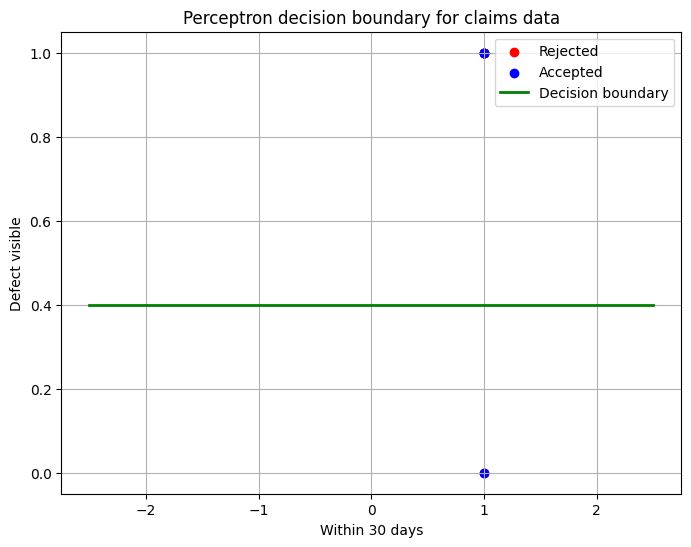

Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 0 0 0 0 0 0]
Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 1 0 0 0 0 0]
Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 1 1 0 0 0 0]
Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 1 1 1 0 0 0]
Weighted Sum: -0.19999999999999998
Predicted Output: 0
Updated Predictions: [1 1 1 1 0 0 0]
Weighted Sum: -0.19999999999999996
Predicted Output: 0
Updated Predictions: [1 1 1 1 0 0 0]
Weighted Sum: -0.19999999999999996
Predicted Output: 0
Updated Predictions: [1 1 1 1 0 0 0]
Confusion Matrix:
[[4 0]
 [0 3]]
[[4 0]
 [0 3]]
Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 0 0 0 0 0 0]
Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 1 0 0 0 0 0]
Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 1 1 0 0 0 0]
Weighted Sum: 0.30000000000000004
Predi

<Figure size 800x600 with 0 Axes>

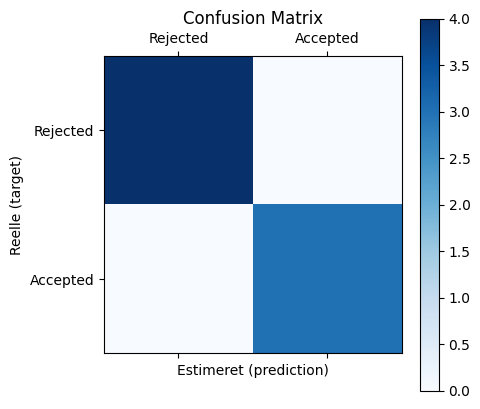

Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 0 0 0 0 0 0]
Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 1 0 0 0 0 0]
Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 1 1 0 0 0 0]
Weighted Sum: 0.30000000000000004
Predicted Output: 1
Updated Predictions: [1 1 1 1 0 0 0]
Weighted Sum: -0.19999999999999998
Predicted Output: 0
Updated Predictions: [1 1 1 1 0 0 0]
Weighted Sum: -0.19999999999999996
Predicted Output: 0
Updated Predictions: [1 1 1 1 0 0 0]
Weighted Sum: -0.19999999999999996
Predicted Output: 0
Updated Predictions: [1 1 1 1 0 0 0]


array([[3, 0],
       [0, 4]])

In [18]:
from sklearn.metrics import confusion_matrix

# Remove claim_number (not relevant for training), and set handling as target
training_data = claims_data.drop(columns=["claim_number"])
target_labels = training_data.pop("handling") # Extract the target labels

# Convert to numpy arrays
X_claims = np.array(training_data)
y_claims = np.array(target_labels)
print("X_claims: ", X_claims)
print("Target: ", y_claims)

# Initialize the perceptron with 2 input features
p = PyPerceptron(learning_rate=0.1, n_epochs=1000, activation_function=heaviside_step, init_weight_value=0.5)

X_claims_data = p.fit(X_claims)
p.train(X_claims_data, y_claims)

plot_decision_boundary_claims_2d(p.weights, X_claims_data, y_claims, plot_title="Perceptron decision boundary for claims data", X_label="Within 30 days", y_label="Defect visible", decision_boundary_label="Decision boundary")


print(p.confusion_matrix(y_claims, p.predict(X_claims_data)))

plt.figure(figsize=(8, 6))
plt.matshow(p.confusion_matrix(y_claims, p.predict(X_claims_data)), cmap='Blues', interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Estimeret (prediction)")
plt.ylabel("Reelle (target)")
plt.xticks([0, 1], ["Rejected", "Accepted"])
plt.yticks([0, 1], ["Rejected", "Accepted"])
plt.show()
confusion_matrix(y_claims, p.predict(X_claims_data), labels=[0, 1])